## Deep Learning, DL Models, and Applications

Skill Development Tasks

```python
# Task 1: Vectorized Multi-Layer Perceptron (MLP) Forward & Backward
# Pass from Scratch
# ● Objective: Master the mathematical foundations of gradient descent by deriving and
# implementing multi-layer backpropagation equations using raw matrix calculus from first
# principles.
# ● Required Tech Stack: Pure NumPy, Python 3.10+, Jupyter Notebook.
# ● Task Description: Students must implement a fully connected neural network with
# arbitrary hidden layer dimensions from scratch. The code must handle batch-wise forward
# passes, calculate cross-entropy loss, derive layer-wise local Jacobians, and execute
# backward weight adjustments using raw 3D matrix transformations without PyTorch's
# autograd.
```

In [23]:
# Step 1 Import Libraries
# Import the NumPy library for numerical operations, aliasing it as 'np'.
import numpy as np
import matplotlib.pyplot as plt

# Set the random seed for NumPy to ensure reproducibility of random operations.
np.random.seed(42)

In [24]:
#Step 2 Create Dataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [25]:
import numpy as np

num_classes = 2

Y_train = np.eye(num_classes)[y_train]
Y_test = np.eye(num_classes)[y_test]

In [26]:
#Step 3 Initialize Parameters
input_size = 2
hidden1 = 16
hidden2 = 8
output_size = 2

W1 = np.random.randn(input_size, hidden1) * 0.01
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * 0.01
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size) * 0.01
b3 = np.zeros((1, output_size))

In [27]:
#Step 4 Activation Functions
def relu(Z):
    return np.maximum(0, Z)


In [28]:
def relu_derivative(Z):
    return (Z > 0).astype(float)

In [29]:
def softmax(Z):

    exp = np.exp(Z - np.max(Z, axis=1, keepdims=True))

    return exp / np.sum(exp, axis=1, keepdims=True)

In [30]:
#Step 5 Forward Propagation
def forward(X):

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    cache = (Z1,A1,Z2,A2,Z3,A3)

    return A3, cache

In [31]:
#Step 6 Cross Entropy Loss
def compute_loss(Y, predictions):

    m = Y.shape[0]

    loss = -np.sum(Y*np.log(predictions+1e-9))/m

    return loss

In [32]:
#Step 7 Backpropagation
def backward(X, Y, cache):

    global W1,W2,W3,b1,b2,b3

    Z1,A1,Z2,A2,Z3,A3 = cache

    m = X.shape[0]

    dZ3 = (A3 - Y)/m

    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3,axis=0,keepdims=True)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2,axis=0,keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1,axis=0,keepdims=True)

    gradients = (
        dW1,db1,
        dW2,db2,
        dW3,db3
    )

    return gradients

In [33]:
#Step 8 Gradient Descent
learning_rate = 0.1
def update(gradients):

    global W1,W2,W3,b1,b2,b3

    dW1,db1,dW2,db2,dW3,db3 = gradients

    W1 -= learning_rate*dW1
    b1 -= learning_rate*db1

    W2 -= learning_rate*dW2
    b2 -= learning_rate*db2

    W3 -= learning_rate*dW3
    b3 -= learning_rate*db3

In [34]:
#Step 9 Training Loop
epochs = 1000

losses = []

for epoch in range(epochs):

    predictions, cache = forward(X_train)

    loss = compute_loss(Y_train,predictions)

    gradients = backward(X_train,Y_train,cache)

    update(gradients)

    losses.append(loss)

    if epoch%100==0:
        print(f"Epoch {epoch} Loss : {loss:.4f}")

Epoch 0 Loss : 0.6931
Epoch 100 Loss : 0.6931
Epoch 200 Loss : 0.6931
Epoch 300 Loss : 0.6931
Epoch 400 Loss : 0.6931
Epoch 500 Loss : 0.6931
Epoch 600 Loss : 0.6931
Epoch 700 Loss : 0.6931
Epoch 800 Loss : 0.6931
Epoch 900 Loss : 0.6930


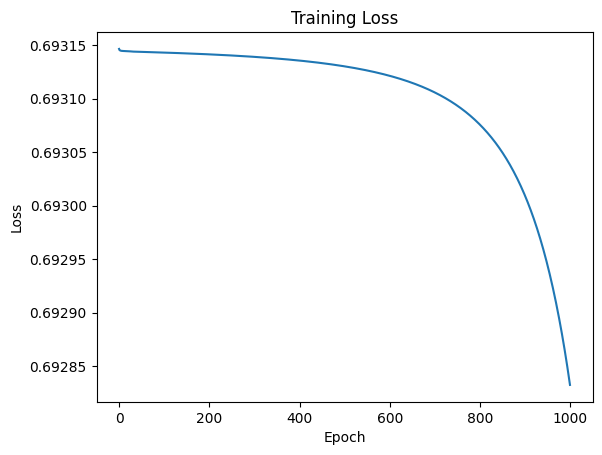

In [35]:
import matplotlib.pyplot as plt

#Step 10 Plot Loss
plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

In [36]:
#Step 11 Prediction
def predict(X):

    predictions,_ = forward(X)

    return np.argmax(predictions,axis=1)

In [37]:
pred = predict(X_test)

accuracy = np.mean(pred==y_test)

print("Accuracy:",accuracy)

Accuracy: 0.775
